# 🏠 House Price Prediction using Linear Regression

## Project Overview
In this project, we will predict house prices based on:
- Square footage of the house
- Number of bedrooms
- Number of bathrooms

## Algorithm Used
- **Linear Regression** (Supervised Machine Learning)

## Libraries Used
- Numpy - for dataset generation
- Pandas - for data manipulation
- Matplotlib & Seaborn - for visualization
- Scikit-learn - for model building and evaluation

In [2]:
# Importing all necessary libraries

import numpy as np                        # for generating random numbers
import pandas as pd                       # for creating and managing dataset
import matplotlib.pyplot as plt           # for plotting graphs
import seaborn as sns                     # for beautiful visualizations
from sklearn.model_selection import train_test_split   # for splitting data
from sklearn.linear_model import LinearRegression      # our main model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # evaluation
import warnings
warnings.filterwarnings('ignore')         # to suppress unnecessary warnings

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [3]:
# Loading the dataset
df = pd.read_csv('train.csv')

# Checking shape of dataset
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

# We only need 4 columns out of 79
# GrLivArea = square footage
# BedroomAbvGr = number of bedrooms
# FullBath = number of bathrooms
# SalePrice = house price

df = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']]

# Renaming columns to simple names
df.columns = ['sqft', 'bedrooms', 'bathrooms', 'price']

# Saving cleaned version as new CSV
df.to_csv('house_prices_cleaned.csv', index=False)

print("Dataset loaded and cleaned successfully! ✅")
print(f"\nTotal houses: {len(df)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset has 1460 rows and 81 columns
Dataset loaded and cleaned successfully! ✅

Total houses: 1460

First 5 rows:


,sqft,bedrooms,bathrooms,price
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


## 🔍 Step 2: Exploratory Data Analysis (EDA)
In this step we explore the dataset to understand its structure, 
check for missing values and see basic statistics.

In [4]:
# Basic information about dataset
print("=== Dataset Info ===")
df.info()

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sqft       1460 non-null   int64
 1   bedrooms   1460 non-null   int64
 2   bathrooms  1460 non-null   int64
 3   price      1460 non-null   int64
dtypes: int64(4)
memory usage: 45.8 KB

=== Basic Statistics ===


,sqft,bedrooms,bathrooms,price
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,1.565068,180921.195890
std,525.480383,0.815778,0.550916,79442.502883
min,334.000000,0.000000,0.000000,34900.000000
25%,1129.500000,2.000000,1.000000,129975.000000
50%,1464.000000,3.000000,2.000000,163000.000000
75%,1776.750000,3.000000,2.000000,214000.000000
max,5642.000000,8.000000,3.000000,755000.000000


In [5]:
# Checking missing values
print("=== Missing Values ===")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== Missing Values ===
sqft         0
bedrooms     0
bathrooms    0
price        0
dtype: int64

Total missing values: 0


## 📊 Step 3: Data Visualization
Visualizing the data to understand patterns and relationships between features and house prices.


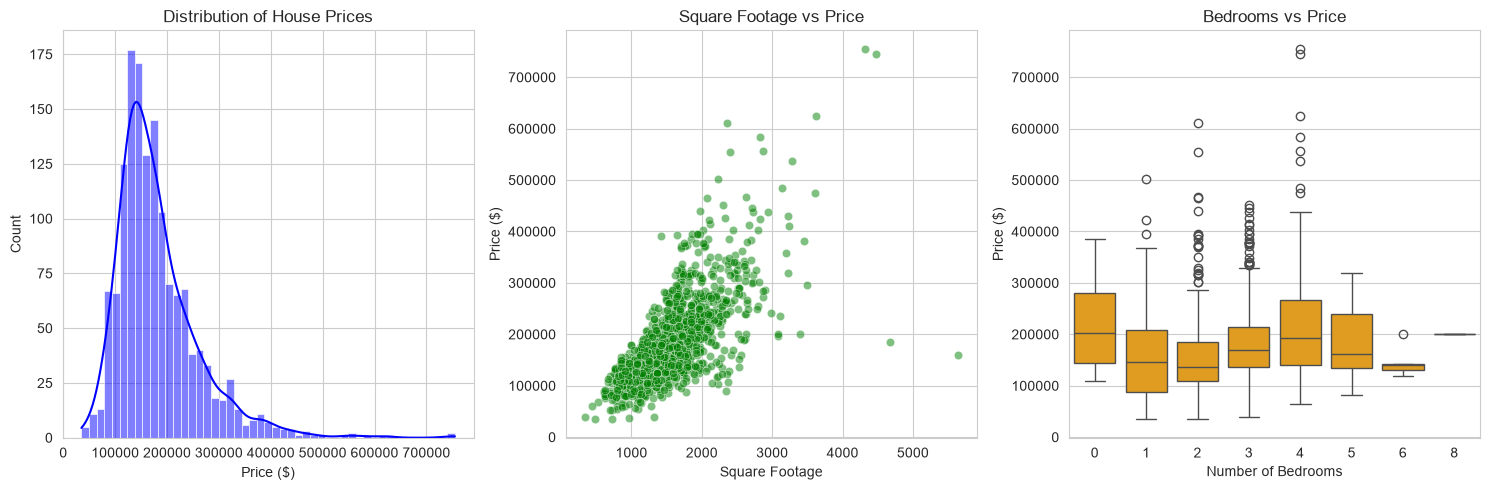

In [6]:
# Setting figure size and style
plt.figure(figsize=(15, 5))
sns.set_style("whitegrid")

# Plot 1 - Distribution of House Prices
plt.subplot(1, 3, 1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')

# Plot 2 - Square Footage vs Price
plt.subplot(1, 3, 2)
sns.scatterplot(x='sqft', y='price', data=df, color='green', alpha=0.5)
plt.title('Square Footage vs Price')
plt.xlabel('Square Footage')
plt.ylabel('Price ($)')

# Plot 3 - Bedrooms vs Price
plt.subplot(1, 3, 3)
sns.boxplot(x='bedrooms', y='price', data=df, color='orange')
plt.title('Bedrooms vs Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

## 🔥 Correlation Heatmap
Correlation tells us how strongly each feature is related to the house price.
Value close to 1 = strong positive relationship
Value close to 0 = weak relationship

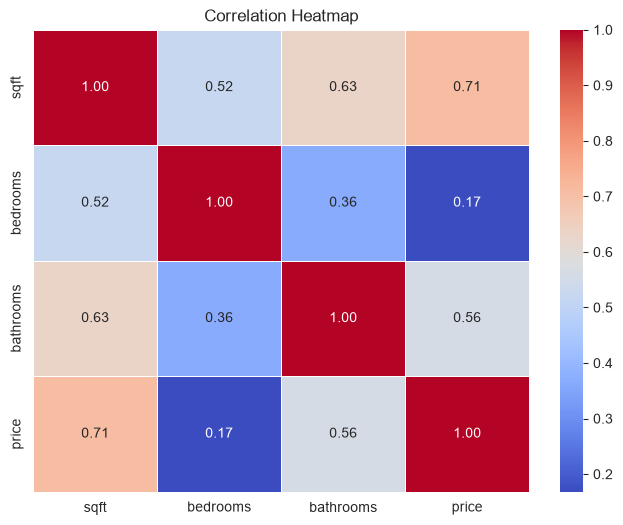

In [7]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## ✂️ Step 4: Preparing Data for Model
Splitting data into:
- X → input features (sqft, bedrooms, bathrooms)
- y → target variable (price)
- 80% data for training, 20% for testing

In [8]:
# Defining features and target
X = df[['sqft', 'bedrooms', 'bathrooms']]   # input features
y = df['price']                              # target variable

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=42)

print(f"Total houses: {len(df)}")
print(f"Training houses: {len(X_train)} (80%)")
print(f"Testing houses: {len(X_test)} (20%)")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Total houses: 1460
Training houses: 1168 (80%)
Testing houses: 292 (20%)

X_train shape: (1168, 3)
X_test shape: (292, 3)


## 🤖 Step 5: Training Linear Regression Model
Now we train our model on the training data.
The model will learn the relationship between sqft, bedrooms, bathrooms and price.

In [9]:
# Creating and training the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully! ✅")
print(f"\n=== Model Coefficients ===")
print(f"Square Footage coefficient : {model.coef_[0]:.2f}")
print(f"Bedrooms coefficient       : {model.coef_[1]:.2f}")
print(f"Bathrooms coefficient      : {model.coef_[2]:.2f}")
print(f"Intercept                  : {model.intercept_:.2f}")

print(f"\n=== Formula Learned by Model ===")
print(f"Price = ({model.coef_[0]:.2f} × sqft) + ({model.coef_[1]:.2f} × bedrooms) + ({model.coef_[2]:.2f} × bathrooms) + {model.intercept_:.2f}")

Model trained successfully! ✅

=== Model Coefficients ===
Square Footage coefficient : 104.03
Bedrooms coefficient       : -26655.17
Bathrooms coefficient      : 30014.32
Intercept                  : 52261.75

=== Formula Learned by Model ===
Price = (104.03 × sqft) + (-26655.17 × bedrooms) + (30014.32 × bathrooms) + 52261.75


In [10]:
# Creating and training the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully! ✅")
print(f"\n=== Model Coefficients ===")
print(f"Square Footage coefficient : {model.coef_[0]:.2f}")
print(f"Bedrooms coefficient       : {model.coef_[1]:.2f}")
print(f"Bathrooms coefficient      : {model.coef_[2]:.2f}")
print(f"Intercept                  : {model.intercept_:.2f}")

print(f"\n=== Formula Learned by Model ===")
print(f"Price = ({model.coef_[0]:.2f} × sqft) + ({model.coef_[1]:.2f} × bedrooms) + ({model.coef_[2]:.2f} × bathrooms) + {model.intercept_:.2f}")

Model trained successfully! ✅

=== Model Coefficients ===
Square Footage coefficient : 104.03
Bedrooms coefficient       : -26655.17
Bathrooms coefficient      : 30014.32
Intercept                  : 52261.75

=== Formula Learned by Model ===
Price = (104.03 × sqft) + (-26655.17 × bedrooms) + (30014.32 × bathrooms) + 52261.75


## 📈 Step 6: Model Evaluation
Evaluating how well our model performs using:
- R² Score → how well model fits data (closer to 1 = better)
- RMSE → average prediction error in dollars
- MAE → mean absolute error in dollars

In [11]:
# Making predictions on test data
y_pred = model.predict(X_test)

# Calculating evaluation metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("=== Model Evaluation Results ===")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : ${rmse:,.2f}")
print(f"MAE      : ${mae:,.2f}")

print(f"\n=== What this means ===")
print(f"Model explains {r2*100:.2f}% of variance in house prices")
print(f"Average prediction error: ${mae:,.2f}")

=== Model Evaluation Results ===
R² Score : 0.6341
RMSE     : $52,975.72
MAE      : $35,788.06

=== What this means ===
Model explains 63.41% of variance in house prices
Average prediction error: $35,788.06


## 📊 Step 7: Prediction Visualizations
Visualizing how well our model predictions match actual prices.

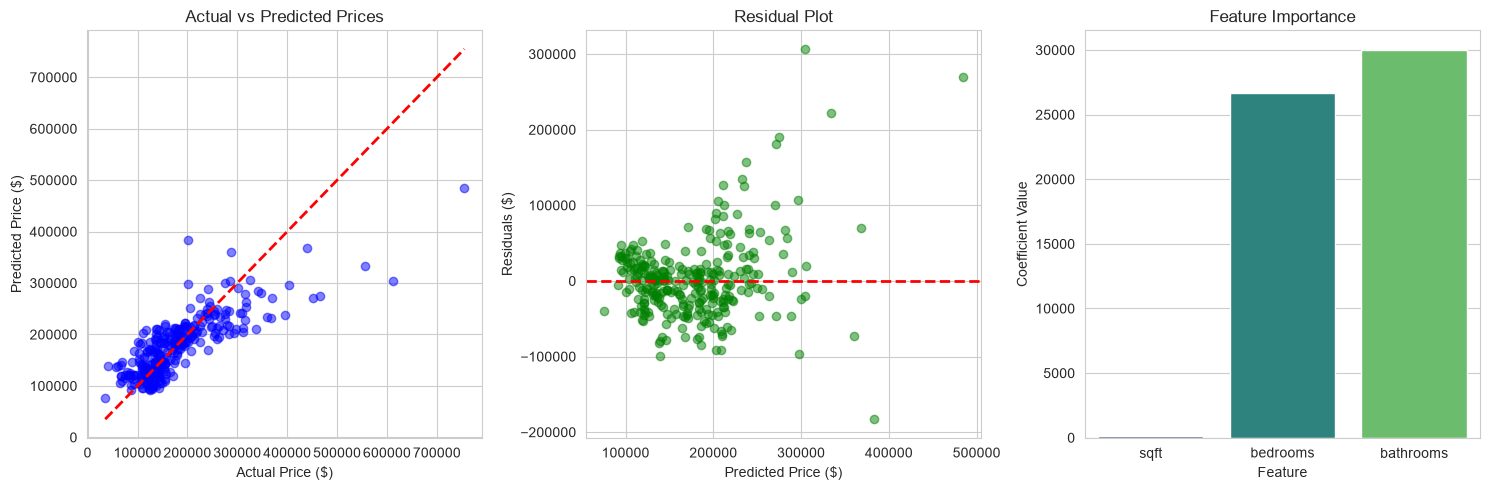

In [12]:
plt.figure(figsize=(15, 5))

# Plot 1 - Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

# Plot 2 - Residual Plot
plt.subplot(1, 3, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals ($)')

# Plot 3 - Feature Importance
plt.subplot(1, 3, 3)
feature_importance = pd.DataFrame({
    'Feature': ['sqft', 'bedrooms', 'bathrooms'],
    'Coefficient': np.abs(model.coef_)
})
sns.barplot(x='Feature', y='Coefficient', data=feature_importance, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')

plt.tight_layout()
plt.show()

## 🎯 Step 8: Predicting Prices for New Houses
Testing our model on brand new houses it has never seen before.

In [13]:
# Creating new houses to predict
new_houses = pd.DataFrame({
    'sqft'      : [1500, 2500, 3500],
    'bedrooms'  : [2, 3, 4],
    'bathrooms' : [1, 2, 3]
})

# Predicting prices
predicted_prices = model.predict(new_houses)

print("=== Predictions for New Houses ===\n")
for i in range(len(new_houses)):
    print(f"House {i+1}:")
    print(f"  Square Footage : {new_houses['sqft'][i]} sqft")
    print(f"  Bedrooms       : {new_houses['bedrooms'][i]}")
    print(f"  Bathrooms      : {new_houses['bathrooms'][i]}")
    print(f"  Predicted Price: ${predicted_prices[i]:,.2f}")
    print()

=== Predictions for New Houses ===

House 1:
  Square Footage : 1500 sqft
  Bedrooms       : 2
  Bathrooms      : 1
  Predicted Price: $185,005.20

House 2:
  Square Footage : 2500 sqft
  Bedrooms       : 3
  Bathrooms      : 2
  Predicted Price: $292,390.67

House 3:
  Square Footage : 3500 sqft
  Bedrooms       : 4
  Bathrooms      : 3
  Predicted Price: $399,776.13

